In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# **EDA** 

In [2]:
import hashlib
import matplotlib.pyplot as plt
import re
from collections import Counter
import warnings
import random
import joblib
import gc
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import lightgbm as lgb
import xgboost as xgb

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer
)
from scipy.sparse import csr_matrix, hstack, vstack
import wandb

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_options = 5

LABEL2IDX= { "A" :0, "B": 1, "C" : 2, "D" : 3, "E" : 4}

IDX2LABEL = {v:k for k,v in LABEL2IDX.items()}


DATA_DIR = "/kaggle/input/"

OUTPUT_DIR = "/kaggle/working/"

os.makedirs(OUTPUT_DIR, exist_ok = True)



In [4]:
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
train.head()
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


Shape and columns of train and test data

In [5]:
print("Train shape:", train.shape)
print("\nTest shape:", test.shape)
print("\nTrain cloumns:", list(train.columns))
print("\nTest columns:", list(test.columns))

Train shape: (2000, 8)

Test shape: (500, 7)

Train cloumns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']

Test columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


Missing values in train and test datasets

In [6]:

def clean_text(text):

    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub("<.*?>"," ",text)
    text = re.sub("\s+"," ",text)
    return text.strip()

def apk(actual,predicted,k=3):

    predicted = predicted[:k]
    score = 0
    hits = 0
    for i,p in enumerate(predicted):
        if p==actual and p not in predicted[:i]:
            hits += 1
            score += hits/(i+1)
    return score

def mapk(actuals,predicteds,k=3):

    return np.mean([apk(a,p,k) for a,p in zip(actuals,predicteds)])
def prediction_to_labels(probabilities):
    top = np.argsort(-probabilities,axis=1)
    preds = [[IDX2LABEL[i] for i in row[:3]] for row in top]
    return preds
def evaluate(probabilities,answers):

    preds = prediction_to_labels(probabilities)

    map3 = mapk(answers,preds)

    top1 = np.argmax(probabilities,axis=1)

    acc = accuracy_score([LABEL2IDX[a] for a in answers],top1)

    f1 = f1_score([LABEL2IDX[a] for a in answers],top1,average="macro")

    print(f"Accuracy : {acc:.5f}")

    print(f"Macro F1 : {f1:.5f}")

    print(f"MAP@3     : {map3:.5f}")

    return acc,f1,map3
def strip_boilerplate(text):
    text = clean_text(text)
    patterns = [
        r"pick the best possible answer:?",
        r"choose the correct answer:?",
        r"which of the following is correct:?",
        r"which of the following statements is true:?",
        r"select the best option:?",
        r"what is the correct answer:?"
    ]

    for pattern in patterns:
        text = re.sub(pattern,"",text,flags=re.IGNORECASE)

    return text.strip()

In [7]:
print("Missing values in train:", train.isnull().sum())
print("Missing values in test:", test.isnull().sum())

Missing values in train: id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
Missing values in test: id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [8]:
answer_counts = train["answer"].value_counts()
print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


Text(0, 0.5, 'Count')

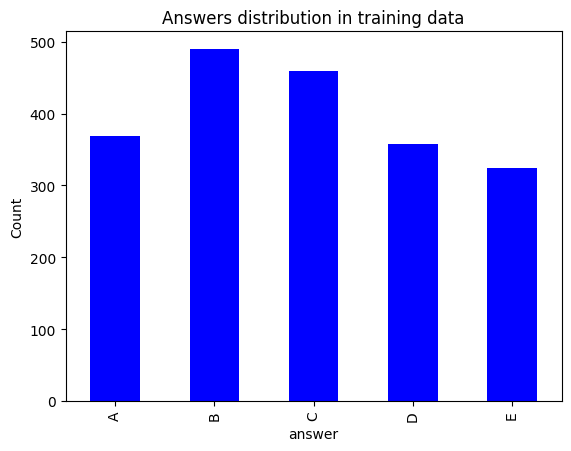

In [9]:
answer_counts.sort_index().plot(kind="bar", color="b",title="Answers distribution in training data")
plt.ylabel("Count")

In [10]:
dup_in_train = train.duplicated(subset=["prompt", "A","B","C","D","E"]).sum()
print("Total duplicates rows/questions which also have same options :",dup_in_train)

Total duplicates rows/questions which also have same options : 183


In [11]:
OPTIONS = ["A","B","C","D","E"]
def option_hash(row):
    key = "|".join(str(row[c]).strip().lower() for c in OPTIONS)
    return hashlib.md5(key.encode()).hexdigest()

train["Question_hash"] = train.apply(option_hash, axis=1)
test["Question_hash"] = test.apply(option_hash, axis=1)
print("Train Hashes:\n",train["Question_hash"])
print("Test Hashes:\n",test["Question_hash"])

Train Hashes:
 0       f357d591b31b3eba240ca8d942833833
1       c35a7aba1a83f5a441971035bc99d7ef
2       6a9b81d55d1bad0b7308c5162ae1f87e
3       f357d591b31b3eba240ca8d942833833
4       d1be288b8262aa1f5824c66f59b4a79e
                      ...               
1995    a0853108228c61d2a5a301742f276e18
1996    7c5f672eea96463a042583f9f50f8caf
1997    fd20c67c0da057beb21c8ebce3111d5e
1998    8bed18ff710ff3cf0a56f5df0958659e
1999    8c26830d7bd7c6842010ddf25de7f6f0
Name: Question_hash, Length: 2000, dtype: object
Test Hashes:
 0      d17c7a7a5f59f015c8db6b3babf37ae2
1      97589c5fd21a4117ef6c744c76823447
2      a0041984581a151e045a2f936d568495
3      314b033197504a1c8147d39eda238305
4      f5901bf99f5c7650da0989ec3591c0f5
                     ...               
495    cbe762150e1da58ad0920d06ab4458cd
496    ea70cf0b200dc407351bbaeea4031c15
497    b85da30e7bdaea4241fd934b1e1d012d
498    3e52eb92dd7d305a4506276e6fc0ca64
499    ad0edb2f209823eae1a9a63a290788f6
Name: Question_hash, Length: 50

In [12]:
print("Unique Questions in Train out of total questions:\n", train["Question_hash"].nunique(),"/",len(train))
print("Unique Questions in Test out of total questions:\n", test["Question_hash"].nunique(),"/",len(test))

Unique Questions in Train out of total questions:
 588 / 2000
Unique Questions in Test out of total questions:
 269 / 500


In [13]:
overlap_hash = set(test["Question_hash"]).intersection(set(train["Question_hash"]))
pct = len(overlap_hash) / test["Question_hash"].nunique() * 100
print(f"{len(overlap_hash)} of {test['Question_hash'].nunique()} unique test questions ")
print(f"({pct:.1f}%) reuse the exact same option set as a train question.")

227 of 269 unique test questions 
(84.4%) reuse the exact same option set as a train question.


In [14]:
answers_per_group = train.groupby("Question_hash")["answer"].nunique()
n_inconsistent = (answers_per_group > 1).sum()
print("Question groups with inconsistent answers:",n_inconsistent)
print("out of",train['Question_hash'].nunique())

Question groups with inconsistent answers: 0
out of 588


In [15]:
def longest_option(row):
    lengths = {opt: len(str(row[opt])) for opt in OPTIONS}
    return max(lengths, key=lengths.get)
 
train["longest_opt"] = train.apply(longest_option, axis=1)
match_rate = (train["longest_opt"] == train["answer"]).mean()*100
print(f"Longest-option heuristic accuracy: {match_rate:.3f}")

Longest-option heuristic accuracy: 40.550


In [16]:
dedup = train.drop_duplicates(subset="Question_hash")
print(f"Answer count after removing the duplicates{dedup["answer"].value_counts()}")
print(f"Answer count before the removing the duplicates:{train["answer"].value_counts()}")

Answer count after removing the duplicatesanswer
C    165
B    134
D    123
E     87
A     79
Name: count, dtype: int64
Answer count before the removing the duplicates:answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


In [17]:
for column in ["prompt"] + OPTIONS:
    n_empty = (train[column].astype(str).str.strip() == "").sum()
    print(f"Empty or whitespaces values in '{column}':{n_empty}")
def has_non_ascii(s):
    return any(ord(c) >127 for c in str(s))
n_non_ascii = train["prompt"].apply(has_non_ascii).sum()
print(f"Prompts containing non-ASCII characters: {n_non_ascii}")
if n_non_ascii:
    print(train.loc[train["prompt"].apply(has_non_ascii), "prompt"].head(3).tolist())

Empty or whitespaces values in 'prompt':0
Empty or whitespaces values in 'A':0
Empty or whitespaces values in 'B':0
Empty or whitespaces values in 'C':0
Empty or whitespaces values in 'D':0
Empty or whitespaces values in 'E':0
Prompts containing non-ASCII characters: 12
['Select the most accurate option: What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy? from the following choices.', 'What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy?', 'Determine the correct option: What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy? among the listed options.']


In [18]:
def clean_prompt(p):
    p = re.sub(r"^[A-Za-z ,]+:\s*","",str(p))
    p = re.sub(r"(among the listed options\.|frm the following choices\.|carefully|.)$","",p)
    return p
    
def word_overlap(prompt_words, opt_text):
    opt_words = set(re.findall(r"\w+", str(opt_text).lower()))
    return len(prompt_words & opt_words)

ranks = []
for _, row in train.iterrows():
    prompt_words = set(re.findall(r"\w+", clean_prompt(row["prompt"]).lower()))
    overlaps = {opt : word_overlap(prompt_words, row[opt]) for opt in OPTIONS}
    sorted_opts = sorted(overlaps, key=lambda k: -overlaps[k])
    ranks.append(sorted_opts.index(row["answer"]) + 1)


train["overlap_rank"] = ranks
print(f"Correct answer's word overlap rank vs the prompt: {train["overlap_rank"].value_counts().sort_index()}")
print(f"Mean rank: {train["overlap_rank"].mean():.5f}")

Correct answer's word overlap rank vs the prompt: overlap_rank
1    384
2    489
3    420
4    366
5    341
Name: count, dtype: int64
Mean rank: 2.89550


In [19]:
n_test_dupe_prompts = test["prompt"].duplicated().sum()
n_test_dupe_full = test.duplicated(subset=["prompt"] + OPTIONS).sum()
print(f"Duplicate prompts in test: {n_test_dupe_prompts}")
print(f"Fully duplicate rows in test: {n_test_dupe_full}")


domains = {
    "Physics": ["quantum", "energy", "force", "particle", "velocity", "gravity", "wave", "electron", "magnetic", "relativity"],
    "Biology": ["cell", "organism", "gene", "protein", "species", "evolution", "enzyme", "dna"],
    "Chemistry": ["molecule", "reaction", "acid", "compound", "element", "bond", "solution"],
    "Astronomy": ["star", "planet", "galaxy", "orbit", "universe", "solar", "black hole"],
    "Philosophy": ["ethics", "existential", "philosopher", "metaphysic", "moral", "consciousness"],
    "CS/Math": ["algorithm", "function", "equation", "matrix", "probability", "computation"],
}

def tag_domain(text):
    t = str(text).lower()
    for domain, kws in domains.items():
        if any(kw in t for kw in kws):
            return domain
    return "Other/Unclassified"
 
train["domain_guess"] = train["prompt"].apply(tag_domain)
print(train["domain_guess"].value_counts())

all_words = []
for p in train["prompt"]:
    cleaned = clean_prompt(p).lower()
    all_words.extend(re.findall(r"[a-z]{4,}", cleaned))  # words with 4+ letters
 
stopwords = {"what", "which", "does", "that", "with", "from", "this", "have",
             "following", "best", "most", "would", "when", "should"}
filtered = [w for w in all_words if w not in stopwords]
top_words = Counter(filtered).most_common(20)
print("Top 20 content words across all prompts:")
for word, count in top_words:
    print(f"  {word}: {count}")


Duplicate prompts in test: 8
Fully duplicate rows in test: 7
domain_guess
Other/Unclassified    1346
Physics                319
Astronomy              172
CS/Math                 84
Biology                 56
Chemistry               23
Name: count, dtype: int64
Top 20 content words across all prompts:
  based: 414
  context: 388
  given: 376
  choices: 369
  carefully: 329
  correct: 282
  between: 240
  relationship: 148
  reason: 103
  used: 102
  effect: 95
  significance: 91
  observed: 85
  statements: 82
  quantum: 72
  accurately: 71
  symmetry: 69
  main: 68
  physics: 67
  space: 64


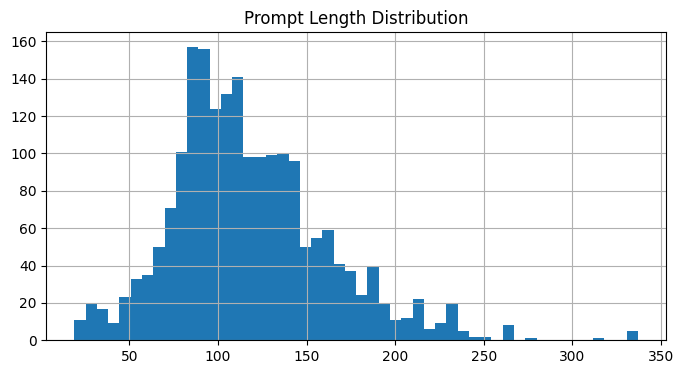

In [20]:
train["prompt_len"] = train["prompt"].str.len()

plt.figure(figsize=(8,4))
train["prompt_len"].hist(bins=50)
plt.title("Prompt Length Distribution")
plt.show()

<Axes: >

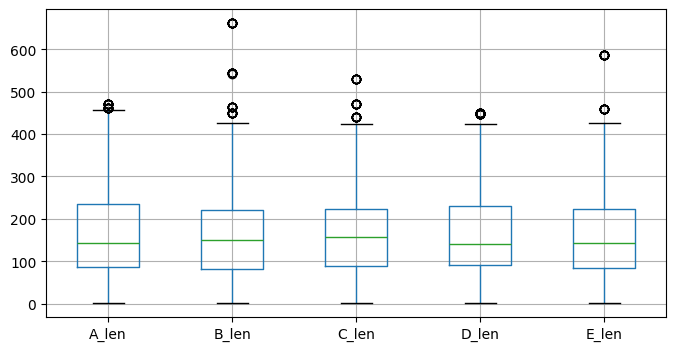

In [21]:
for col in OPTIONS:
    train[col+"_len"] = train[col].astype(str).str.len()
length_df = train[[c+"_len" for c in OPTIONS]]

length_df.boxplot(figsize=(8,4))

# **Feature Enginerring**


In [22]:
train["option_set"] = train[["A","B","C","D","E"]].apply(lambda x: " | ".join([str(i).strip() for i in x]),axis=1)

test["option_set"] = test[["A","B","C","D","E"]].apply(lambda x: " | ".join([str(i).strip() for i in x]),axis=1)

lookup_map = {}

for _,row in train.iterrows():

    lookup_map[row["option_set"]] = row["answer"]

print(f"Lookup size : {len(lookup_map)}")

Lookup size : 588


In [23]:
all_prompt = pd.concat([train["prompt"],test["prompt"]]).apply(clean_text)
all_options =[]
for col in ["A","B","C","D","E"]:
    all_options.extend(train[col].apply(clean_text))
    all_options.extend(test[col].apply(clean_text))

corpus = list(all_prompt) + all_options

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2),stop_words="english",sublinear_tf=True)

tfidf.fit(corpus)

print("vocabulary:", len(tfidf.vocabulary_))


vocabulary: 3000


In [24]:
OPTION_COLS = ["A", "B", "C", "D", "E"]

def build_joint_text(df):

    pairs = []

    for _, row in df.iterrows():

        prompt = strip_boilerplate(
            clean_text(str(row["prompt"]))
        )

        for col in OPTION_COLS:

            option = clean_text(str(row[col]))

            pairs.append(prompt + " " + option)

    return pairs


train_joint = build_joint_text(train)
test_joint = build_joint_text(test)

joint_tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    stop_words="english",
    sublinear_tf=True
)

joint_tfidf.fit(train_joint)

X_joint_train = joint_tfidf.transform(train_joint)
X_joint_test = joint_tfidf.transform(test_joint)

print("Joint TF-IDF ready.")

Joint TF-IDF ready.


In [25]:
svd = TruncatedSVD(n_components=16, random_state=42)

svd.fit(tfidf.transform(corpus))


TruncatedSVD(n_components=16, random_state=42)

In [26]:
os.makedirs("models", exist_ok=True)

joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(joint_tfidf, "models/joint_tfidf.pkl")
joblib.dump(svd, "models/svd.pkl")

print("Vectorizers saved successfully.")

Vectorizers saved successfully.


In [27]:
NEGATION_WORDS = {
    "no","not","never","none","neither","nor",
    "cannot","without","n't","false","unlike"
}
ABSOLUTE_WORDS = {
    "always","all","every","entirely",
    "absolutely","completely","only",
    "must","true"
}
UNITS_WORDS = {
    "kg","cm","mm","m","km","hz",
    "mol","nm","v","w","ev","kj",
    "pa","atm","sec","min","hr"
}
def get_longest_common_prefix(strings):

    if len(strings)==0:
        return ""

    s1=min(strings)
    s2=max(strings)

    for i,c in enumerate(s1):

        if c!=s2[i]:
            return s1[:i]
    return s1
def jaccard_similarity(a,b):
    a=set(a)
    b=set(b)
    return len(a&b)/(len(a|b)+1e-9)
def cosine_score(vec1,vec2):

    return cosine_similarity(vec1,vec2)[0,0]
def similarity_features(prompt_words,
                        option_words,
                        prompt_vec,
                        option_vec):

    overlap=len(

        prompt_words.intersection(option_words)
    )
    union=len(
        prompt_words.union(option_words)
    )
    jaccard=overlap/(union+1e-6)
    cosine=cosine_score(
        prompt_vec,
        option_vec
    )
    overlap_ratio=overlap/(
        min(len(prompt_words),
            len(option_words))+1e-6
    )
    return {
        "cosine":cosine,
        "jaccard":jaccard,
        "overlap":overlap_ratio}

In [28]:
def length_features(option_length,all_lengths,rank):
    mean=np.mean(all_lengths)
    std=np.std(all_lengths)+1e-6
    return {
        "len_rank":rank,
        "len_z":(option_length-mean)/std,
        "len_ratio":option_length/(mean+1e-6),
        "longest":int(rank==1),
        "shortest":int(rank==5)
    }

def lookup_features(option_set,option_label):

    if option_set in lookup_map:
        return {"known":1,"lookup_match":int(lookup_map[option_set]==option_label)}

    return {
        "known":0,
        "lookup_match":0
    }

In [29]:
def option_statistics(text):

    words=text.lower().split()

    chars=len(text)

    alpha=max(

        sum(c.isalpha() for c in text),

        1

    )

    return {

        "negation":

        sum(

            w in NEGATION_WORDS

            for w in words

        ),

        "absolute":
        sum(
            w in ABSOLUTE_WORDS
            for w in words
        ),
        "digit_ratio":
        sum(
            c.isdigit()
            for c in text
        )/(chars+1e-6),
        "uppercase_ratio":
        sum(c.isupper() for c in text)/alpha,"contains_unit": int(any(w in UNITS_WORDS for w in words))}

In [30]:
OPTION_COLS = ["A", "B", "C", "D", "E"]

def prepare_text_data(df):
    """
    Precompute all text representations required for feature engineering.
    """
    data = {}
    data["prompt_clean"] = df["prompt"].fillna("").apply(clean_text)
    data["prompt_core"] = (df["prompt"].fillna("").apply(strip_boilerplate))

    data["prompt_tfidf"] = tfidf.transform(data["prompt_core"])

    data["prompt_svd"] = svd.transform(data["prompt_tfidf"])

    data["options_clean"] = {}

    data["options_tfidf"] = {}

    data["options_svd"] = {}

    for col in OPTION_COLS:

        texts = (df[col].fillna("").astype(str).apply(clean_text))
        data["options_clean"][col] = texts

        tfidf_vec = tfidf.transform(texts)

        data["options_tfidf"][col] = tfidf_vec

        data["options_svd"][col] = svd.transform(tfidf_vec)
    data["option_set"] = df[OPTION_COLS].apply(lambda x: " | ".join(str(v).strip() for v in x),axis=1).values
    return data
print("Feature preparation utilities ready.")

Feature preparation utilities ready.


In [31]:
def basic_features(row_idx,option_idx,option_label,text_data,lookup_map):
    """
    Returns a dictionary of basic engineered features.
    """

    feat = {}

    prompt_text = text_data["prompt_core"].iloc[row_idx]

    prompt_words = prompt_text.lower().split()

    prompt_word_cnt = max(len(prompt_words), 1)

    prompt_char_cnt = max(len(prompt_text), 1)

    option_text = (text_data["options_clean"][option_label].iloc[row_idx])

    option_words = option_text.lower().split()

    option_word_cnt = max(len(option_words), 1)

    option_char_cnt = len(option_text)

    row_options = [text_data["options_clean"][c].iloc[row_idx] for c in OPTION_COLS]
    char_lengths = [len(x) for x in row_options]
    word_lengths = [len(x.split()) for x in row_options]

    mean_char = np.mean(char_lengths)

    std_char = np.std(char_lengths) + 1e-6

    mean_word = np.mean(word_lengths)

    std_word = np.std(word_lengths) + 1e-6

    ranks = (pd.Series(char_lengths).rank(ascending=False,method="min").values)

    option_set = text_data["option_set"][row_idx]

    feat["char_len"] = option_char_cnt

    feat["word_len"] = option_word_cnt

    feat["len_rank"] = ranks[option_idx]

    feat["is_longest"] = int(ranks[option_idx] == 1)

    feat["is_shortest"] = int(ranks[option_idx] == 5)

    feat["char_zscore"] = (option_char_cnt - mean_char) / std_char

    feat["word_zscore"] = (option_word_cnt - mean_word) / std_word

    feat["char_ratio"] = (option_char_cnt/ (mean_char + 1e-6))

    feat["word_ratio"] = (option_word_cnt/ (mean_word + 1e-6))
    feat["prompt_char_ratio"] = (option_char_cnt/ prompt_char_cnt)
    feat["prompt_word_ratio"] = (option_word_cnt/ prompt_word_cnt)

    feat["lcp_length"] = len(get_longest_common_prefix(row_options))
    return feat

In [32]:
def similarity_features(row_idx, option_idx,option_label,text_data):
    """
    Semantic similarity features between prompt and option.
    """

    feat = {}

    prompt_text = text_data["prompt_core"].iloc[row_idx]

    prompt_words = set(prompt_text.lower().split())

    prompt_vec = (text_data["prompt_tfidf"][row_idx])

    prompt_svd = (text_data["prompt_svd"][row_idx])

    option_text = (text_data["options_clean"][option_label].iloc[row_idx])

    option_words = set(option_text.lower().split())

    option_vec = (text_data["options_tfidf"][option_label][row_idx])

    option_svd = (text_data["options_svd"][option_label][row_idx])

    intersection = len(prompt_words & option_words)

    union = len(prompt_words | option_words)

    feat["word_overlap"] = intersection

    feat["overlap_ratio"] = (intersection /(min(len(prompt_words),len(option_words)) + 1e-6))

    feat["jaccard"] = (intersection /(union + 1e-6))
    feat["tfidf_cosine"] = cosine_similarity(prompt_vec,option_vec)[0, 0]

    feat["svd_cosine"] = (np.dot(prompt_svd, option_svd)/(np.linalg.norm(prompt_svd)*np.linalg.norm(option_svd)+ 1e-6))

    from scipy.sparse import vstack
    option_vectors = vstack([text_data["options_tfidf"][c][row_idx] for c in OPTION_COLS])
    
    sim_matrix = cosine_similarity(option_vectors)
    
    sims = np.delete(sim_matrix[option_idx], option_idx)
    
    feat["opt_sim_mean"] = np.mean(sims)
    feat["opt_sim_max"] = np.max(sims)
    feat["opt_sim_min"] = np.min(sims)
    feat["opt_sim_std"] = np.std(sims)

    row_options = [text_data["options_clean"][c].iloc[row_idx] for c in OPTION_COLS]

    prefix = get_longest_common_prefix(row_options)

    feat["common_prefix_len"] = len(prefix)

    feat["option_prefix_ratio"] = (len(prefix)/(len(option_text) + 1e-6))

    return feat

In [33]:
def advanced_features(row_idx, option_idx, option_label, text_data):
    """
    Advanced handcrafted linguistic features.
    """
    feat = {}

    option_text = text_data["options_clean"][option_label].iloc[row_idx]
    words = option_text.lower().split()
    word_count = max(len(words), 1)
    char_count = max(len(option_text), 1)

    neg_count = sum(w in NEGATION_WORDS for w in words)
    feat["negation_count"] = neg_count
    feat["negation_ratio"] = neg_count / word_count

    abs_count = sum(w in ABSOLUTE_WORDS for w in words)
    feat["absolute_count"] = abs_count
    feat["absolute_ratio"] = abs_count / word_count

    stop_count = sum(w in STOPWORDS for w in words)
    feat["stopword_ratio"] = stop_count / word_count

    digit_count = sum(c.isdigit() for c in option_text)
    feat["digit_ratio"] = digit_count / char_count
    feat["contains_digit"] = int(digit_count > 0)

    unit_present = any(w in UNITS_WORDS for w in words)
    feat["contains_unit"] = int(unit_present)

    alpha_count = sum(c.isalpha() for c in option_text)
    upper_count = sum(c.isupper() for c in option_text)
    feat["uppercase_ratio"] = upper_count / (alpha_count + 1e-6)

    feat["question_marks"] = option_text.count("?")
    feat["comma_count"] = option_text.count(",")
    feat["semicolon_count"] = option_text.count(";")
    feat["colon_count"] = option_text.count(":")
    feat["parenthesis_count"] = option_text.count("(") + option_text.count(")")

    unique_words = len(set(words))
    feat["lexical_diversity"] = unique_words / word_count
    feat["avg_word_length"] = np.mean([len(w) for w in words]) if words else 0

    svd_vec = text_data["options_svd"][option_label][row_idx]
    feat["svd_mean"] = np.mean(svd_vec)
    feat["svd_std"] = np.std(svd_vec)
    feat["svd_max"] = np.max(svd_vec)
    feat["svd_min"] = np.min(svd_vec)
    feat["svd_sum"] = np.sum(svd_vec)
    feat["svd_norm"] = np.linalg.norm(svd_vec)

    return feat

In [34]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOPWORDS = set(ENGLISH_STOP_WORDS)
def extract_features(
    df,
    text_data,
    lookup_map
):
    """
    Generate engineered features for all
    (question, option) pairs.
    """

    feature_rows = []

    labels = []

    groups = []

    for row_idx in tqdm(range(len(df)), desc="Extracting Features"):

        for option_idx, option_label in enumerate(OPTION_COLS):

            feat = {}

            feat.update(

                basic_features(
                    row_idx,
                    option_idx,
                    option_label,
                    text_data,
                    lookup_map
                )

            )

            feat.update(

                similarity_features(
                    row_idx,
                    option_idx,
                    option_label,
                    text_data
                )

            )

            feat.update(

                advanced_features(
                    row_idx,
                    option_idx,
                    option_label,
                    text_data
                )

            )

            feature_rows.append(feat)

            if "answer" in df.columns:

                labels.append(

                    int(
                        option_label
                        == df.iloc[row_idx]["answer"]
                    )

                )

            groups.append(row_idx)

    feature_df = pd.DataFrame(feature_rows)

    return feature_df, labels, groups


train_text = prepare_text_data(train)

X_train_df, y, groups = extract_features(
    train,
    train_text,
    lookup_map
)

print(X_train_df.shape)


test_text = prepare_text_data(test)

X_test_df, _, _ = extract_features(
    test,
    test_text,
    lookup_map
)

print(X_test_df.shape)

def build_joint_text(df):

    texts = []

    for _, row in df.iterrows():

        prompt = strip_boilerplate(
            clean_text(row["prompt"])
        )

        for col in OPTION_COLS:

            texts.append(
                prompt + " " + clean_text(str(row[col]))
            )

    return texts


train_joint = build_joint_text(train)

test_joint = build_joint_text(test)

X_joint_train = joint_tfidf.transform(train_joint)

X_joint_test = joint_tfidf.transform(test_joint)

X_train_dense = csr_matrix(
    X_train_df.values
)

X_test_dense = csr_matrix(
    X_test_df.values
)

X_train = hstack([
    X_train_dense,
    X_joint_train
]).tocsr()

X_test = hstack([
    X_test_dense,
    X_joint_test
]).tocsr()

dense_feature_names = X_train_df.columns.tolist()

feature_names = (
    dense_feature_names +
    [f"tfidf_{i}" for i in range(X_joint_train.shape[1])]
)
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Extracting Features:   0%|          | 0/2000 [00:00<?, ?it/s]

(10000, 45)


Extracting Features:   0%|          | 0/500 [00:00<?, ?it/s]

(2500, 45)
Train: (10000, 4045)
Test : (2500, 4045)


In [35]:
LABELS = ["A", "B", "C", "D", "E"]

label_to_index = {
    label: idx
    for idx, label in enumerate(LABELS)
}

index_to_label = {
    idx: label
    for idx, label in enumerate(LABELS)
}

In [36]:
print("STOPWORDS" in globals())
print("NEGATION_WORDS" in globals())
print("ABSOLUTE_WORDS" in globals())
print("UNITS_WORDS" in globals())
print("OPTION_COLS" in globals())
print("label_to_index" in globals())
print("index_to_label" in globals())

True
True
True
True
True
True
True


In [37]:
train_text = prepare_text_data(train)
test_text = prepare_text_data(test)

X_train_df, y, groups = extract_features(
    train,
    train_text,
    lookup_map
)

X_test_df, _, _ = extract_features(
    test,
    test_text,
    lookup_map
)

print(X_train_df.shape)
print(X_test_df.shape)

Extracting Features:   0%|          | 0/2000 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/500 [00:00<?, ?it/s]

(10000, 45)
(2500, 45)


In [38]:
from scipy.sparse import csr_matrix, hstack

X_train = hstack([
    csr_matrix(X_train_df.values),
    X_joint_train
]).tocsr()

X_test = hstack([
    csr_matrix(X_test_df.values),
    X_joint_test
]).tocsr()

print(X_train.shape)
print(X_test.shape)

(10000, 4045)
(2500, 4045)


In [39]:
print(X_train.shape)
print(X_test.shape)
print(len(y))
print(len(groups))
print(np.isnan(X_train_df.values).sum())
print(np.isnan(X_test_df.values).sum())
print(X_train_dense.shape)
print(X_joint_train.shape)
print(X_train.shape)

(10000, 4045)
(2500, 4045)
10000
10000
0
0
(10000, 45)
(10000, 4000)
(10000, 4045)


In [40]:
y = np.array(y, dtype=np.int8)
question_groups = pd.factorize(train["Question_hash"])[0]
groups = np.repeat(question_groups, 5)
print(type(y))
print(y[:10])
print(np.unique(y, return_counts=True))

<class 'numpy.ndarray'>
[0 1 0 0 0 1 0 0 0 0]
(array([0, 1], dtype=int8), array([8000, 2000]))


In [41]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss
import joblib


N_FOLDS = 5

gkf = GroupKFold(n_splits=N_FOLDS)

lgb_params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "n_estimators": 5000,
    "num_leaves": 63,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity":-1
}
callbacks=[
    early_stopping(200),
    log_evaluation(100),
]


oof_lgb = np.zeros(len(y))
test_lgb = np.zeros(X_test.shape[0])

lgb_models = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X_train, y, groups), start=1):

    print(f"Fold {fold}")

    X_tr = X_train[train_idx]
    X_va = X_train[valid_idx]

    y_tr = y[train_idx]
    y_va = y[valid_idx]

    model = LGBMClassifier(**lgb_params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="binary_logloss",
        callbacks=[
            early_stopping(200),
            log_evaluation(100),
        ],
    )

    oof_lgb[valid_idx] = model.predict_proba(X_va)[:, 1]
    test_lgb += model.predict_proba(X_test)[:, 1] / N_FOLDS
    lgb_models.append(model)

    print("Fold LogLoss:", log_loss(y_va, oof_lgb[valid_idx]))

oof_lgb_matrix = oof_lgb.reshape(len(train), 5)

lgb_accuracy, lgb_f1, lgb_map3 = evaluate(
    oof_lgb_matrix,
    train["answer"].values
)

print(f"Accuracy : {lgb_accuracy:.5f}")
print(f"F1 Score : {lgb_f1:.5f}")
print(f"MAP@3    : {lgb_map3:.5f}")


joblib.dump(lgb_models, "models/lightgbm_models.pkl")

Fold 1
Training until validation scores don't improve for 200 rounds
[100]	valid_0's binary_logloss: 0.37189
[200]	valid_0's binary_logloss: 0.421344
Early stopping, best iteration is:
[82]	valid_0's binary_logloss: 0.365887
Fold LogLoss: 0.36588677612449816
Fold 2
Training until validation scores don't improve for 200 rounds
[100]	valid_0's binary_logloss: 0.42834
[200]	valid_0's binary_logloss: 0.501015
Early stopping, best iteration is:
[57]	valid_0's binary_logloss: 0.405693
Fold LogLoss: 0.4056926404139266
Fold 3
Training until validation scores don't improve for 200 rounds
[100]	valid_0's binary_logloss: 0.447842
[200]	valid_0's binary_logloss: 0.538076
Early stopping, best iteration is:
[50]	valid_0's binary_logloss: 0.40866
Fold LogLoss: 0.40866046564612357
Fold 4
Training until validation scores don't improve for 200 rounds
[100]	valid_0's binary_logloss: 0.426455
[200]	valid_0's binary_logloss: 0.489623
Early stopping, best iteration is:
[56]	valid_0's binary_logloss: 0.41795

['models/lightgbm_models.pkl']

In [63]:
def canonical_prompt(text):
    text = str(text).lower().strip()

    text = re.sub(
        r"^(pick the best possible answer|choose the correct answer|"
        r"select the best option|determine the correct option|"
        r"select the most accurate option|identify the correct option|"
        r"choose the most appropriate answer)\s*:\s*",
        "",
        text
    )

    text = re.sub(
        r"\s*(from the following choices|among the listed options|"
        r"from the choices given|among the given choices)\.?\s*$",
        "",
        text
    )

    return re.sub(r"\s+", " ", text).strip()

def question_key(row):
    prompt = canonical_prompt(row["prompt"])
    options = " || ".join(
        str(row[col]).strip().lower()
        for col in OPTION_COLS
    )
    return prompt + " ### " + options

train_for_lookup = train.copy()
train_for_lookup["question_key"] = train_for_lookup.apply(question_key, axis=1)

answer_counts = train_for_lookup.groupby("question_key")["answer"].nunique()
safe_keys = answer_counts[answer_counts == 1].index

safe_lookup = (
    train_for_lookup[train_for_lookup["question_key"].isin(safe_keys)]
    .groupby("question_key")["answer"]
    .first()
    .to_dict()
)

test_lgb_matrix = test_lgb.reshape(len(test), 5)

predictions = []
matched_count = 0

for row_idx, (_, row) in enumerate(test.iterrows()):
    ranked_indices = np.argsort(-test_lgb_matrix[row_idx])
    ranking = [OPTION_COLS[i] for i in ranked_indices]

    key = question_key(row)

    if key in safe_lookup:
        known_answer = safe_lookup[key]
        ranking = [known_answer] + [
            label for label in ranking if label != known_answer
        ]
        matched_count += 1

    predictions.append(" ".join(ranking[:3]))

print(f"Safe prompt + option matches used: {matched_count}/{len(test)}")

sample = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

submission_v2 = sample[[sample.columns[0]]].copy()
submission_v2[sample.columns[1]] = predictions

submission_v2.to_csv(
    "/kaggle/working/submission_lgb_safe_lookup.csv",
    index=False
)

display(submission_v2.head())

Safe prompt + option matches used: 385/500


,ID,Prediction
0,1,A B E
1,2,B E C
2,3,B E A
3,4,E C A
4,5,C D E


In [68]:
import os

print(os.path.exists("/kaggle/working/submission_lgb_safe_lookup.csv"))
print(os.path.getsize("/kaggle/working/submission_lgb_safe_lookup.csv"))

print(submission.columns.tolist())
print(submission.shape)
display(submission.head())

True
4906
['ID', 'Prediction']
(500, 2)


,ID,Prediction
0,1,A B E
1,2,B E C
2,3,B E A
3,4,E C A
4,5,C D E


In [69]:
audit = test[["id", "prompt"] + OPTION_COLS].copy()

audit["question_key"] = audit.apply(question_key, axis=1)
audit["used_safe_lookup"] = audit["question_key"].isin(safe_lookup)
audit["lookup_answer"] = audit["question_key"].map(safe_lookup)
audit["final_prediction"] = predictions

display(
    audit[
        ["id", "used_safe_lookup", "lookup_answer", "final_prediction", "prompt"]
    ].head(20)
)

print("Rows using safe lookup:", audit["used_safe_lookup"].sum())
print("Rows using LightGBM only:", (~audit["used_safe_lookup"]).sum())

,id,used_safe_lookup,lookup_answer,final_prediction,prompt
0,1,True,A,A B E,Pick the best possible answer: What is the rel...
1,2,True,B,B E C,"What is the estimated redshift of CEERS-93316,..."
2,3,True,B,B E A,Pick the best possible answer: What is the rea...
3,4,True,E,E C A,What is the significance of the redshift-dista...
4,5,True,C,C D E,What is the Landau-Lifshitz-Gilbert equation u...
5,6,False,NaN,D B C,Choose the correct answer: What is the Evans b...
6,7,True,E,E D B,Which of the following is correct? What is Lor...
7,8,True,B,B D C,What are the four qualitative levels of crysta...
8,9,True,C,C D E,What is the Maxwell's Demon thought experiment?
9,10,True,B,B E C,Which of the following is correct? What is the...


Rows using safe lookup: 385
Rows using LightGBM only: 115


In [44]:
print("Engineered features :", len(feature_names))
print("TF-IDF features     :", X_joint_train.shape[1])
print("Total expected      :", len(feature_names) + X_joint_train.shape[1])
print("Model features      :", len(lgb_models[0].feature_importances_))
print(X_train.shape)

Engineered features : 4045
TF-IDF features     : 4000
Total expected      : 8045
Model features      : 4045
(10000, 4045)


In [45]:
print(feature_names[:10])
print(feature_names[45:55])
import pandas as pd

imp = pd.DataFrame({
    "feature": feature_names,
    "importance": lgb_models[0].feature_importances_
})

imp = imp.sort_values("importance", ascending=False)

print(imp.head(50))

['char_len', 'word_len', 'len_rank', 'is_longest', 'is_shortest', 'char_zscore', 'word_zscore', 'char_ratio', 'word_ratio', 'prompt_char_ratio']
['tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9']
                  feature  importance
5             char_zscore         329
7              char_ratio         260
20            opt_sim_std         222
38        avg_word_length         199
27         stopword_ratio         198
39               svd_mean         184
0                char_len         184
6             word_zscore         177
37      lexical_diversity         166
17           opt_sim_mean         157
42                svd_min         156
31        uppercase_ratio         142
18            opt_sim_max         118
8              word_ratio         114
40                svd_std         102
19            opt_sim_min          86
41                svd_max          82
22    option_prefix_ratio          80
2                len_r

In [46]:
'''for var in [
    "train_feat",
    "X_train_dense",
    "X_joint_train",
    "X_train",
    "feature_cols",
    "dense_feature_names",
    "lgb_models"
]:
    print(var, "->", var in globals())'''

'for var in [\n    "train_feat",\n    "X_train_dense",\n    "X_joint_train",\n    "X_train",\n    "feature_cols",\n    "dense_feature_names",\n    "lgb_models"\n]:\n    print(var, "->", var in globals())'

In [47]:
'''print(X_train_dense)
print(X_train_dense.shape)'''

'print(X_train_dense)\nprint(X_train_dense.shape)'

# NEXT model

In [48]:
'''from sklearn.model_selection import GroupKFold
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import log_loss
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
oof_cat = np.zeros(len(y))
test_pred_cat = np.zeros(X_test.shape[0])

cat_models = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X_train, y, groups)):
    print(f"Fold {fold+1}")

    train_pool = Pool(
        X_train[train_idx],
        y[train_idx]
    )

    valid_pool = Pool(
        X_train[valid_idx],
        y[valid_idx]
    )

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        verbose=200,
        task_type="GPU",
        devices="0"
    )
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
        early_stopping_rounds=200
    )
    oof_cat[valid_idx] = model.predict_proba(X_train[valid_idx])[:, 1]
    test_pred_cat += (model.predict_proba(X_test)[:, 1]/ gkf.n_splits)

    cat_models.append(model)

    print(
        "Fold LogLoss:",
        log_loss(
            y[valid_idx],
            oof_cat[valid_idx]
        )
    )

print("Overall OOF:", log_loss(y, oof_cat))'''

'from sklearn.model_selection import GroupKFold\nfrom catboost import CatBoostClassifier, Pool\nfrom sklearn.metrics import log_loss\nfrom sklearn.model_selection import GroupKFold\n\ngkf = GroupKFold(n_splits=5)\noof_cat = np.zeros(len(y))\ntest_pred_cat = np.zeros(X_test.shape[0])\n\ncat_models = []\n\nfor fold, (train_idx, valid_idx) in enumerate(gkf.split(X_train, y, groups)):\n    print(f"Fold {fold+1}")\n\n    train_pool = Pool(\n        X_train[train_idx],\n        y[train_idx]\n    )\n\n    valid_pool = Pool(\n        X_train[valid_idx],\n        y[valid_idx]\n    )\n\n    model = CatBoostClassifier(\n        loss_function="Logloss",\n        eval_metric="Logloss",\n        iterations=5000,\n        learning_rate=0.03,\n        depth=8,\n        l2_leaf_reg=5,\n        random_seed=42,\n        verbose=200,\n        task_type="GPU",\n        devices="0"\n    )\n    model.fit(\n        train_pool,\n        eval_set=valid_pool,\n        use_best_model=True,\n        early_stopping

In [49]:
'''!pip -q install -U transformers datasets accelerate evaluate sentencepiece
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss'''

'!pip -q install -U transformers datasets accelerate evaluate sentencepiece\nfrom datasets import Dataset\n\nfrom transformers import (\n    AutoTokenizer,\n    AutoModelForSequenceClassification,\n    TrainingArguments,\n    Trainer\n)\n\nfrom sklearn.model_selection import GroupKFold\nfrom sklearn.metrics import log_loss'

In [50]:
'''train_rows = []

for i, row in train.iterrows():

    prompt = row["prompt"]

    for option in OPTION_COLS:

        train_rows.append({

            "text": prompt + " [SEP] " + str(row[option]),

            "label": int(option == row["answer"]),

            "group": i

        })

train_df = pd.DataFrame(train_rows)

train_df.head()

test_rows = []

for _, row in test.iterrows():

    prompt = row["prompt"]

    for option in OPTION_COLS:

        test_rows.append({

            "text": prompt + " [SEP] " + str(row[option])

        })

test_df = pd.DataFrame(test_rows)
'''

'train_rows = []\n\nfor i, row in train.iterrows():\n\n    prompt = row["prompt"]\n\n    for option in OPTION_COLS:\n\n        train_rows.append({\n\n            "text": prompt + " [SEP] " + str(row[option]),\n\n            "label": int(option == row["answer"]),\n\n            "group": i\n\n        })\n\ntrain_df = pd.DataFrame(train_rows)\n\ntrain_df.head()\n\ntest_rows = []\n\nfor _, row in test.iterrows():\n\n    prompt = row["prompt"]\n\n    for option in OPTION_COLS:\n\n        test_rows.append({\n\n            "text": prompt + " [SEP] " + str(row[option])\n\n        })\n\ntest_df = pd.DataFrame(test_rows)\n'

In [51]:
'''MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 256

def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LEN

    )


dataset = Dataset.from_pandas(train_df)

dataset = dataset.map(
    tokenize,
    batched=True
)

dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)


test_dataset = Dataset.from_pandas(test_df)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask"
    ]
)


groups = train_df["group"].values

labels = train_df["label"].values

gkf = GroupKFold(n_splits=5)

training_args = TrainingArguments(

    output_dir="./deberta",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    fp16=True,

    logging_steps=100,

    save_strategy="no",

    report_to="none"

)

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2

)

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset

)

trainer.train()'''

'MODEL_NAME = "microsoft/deberta-v3-base"\n\ntokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)\nMAX_LEN = 256\n\ndef tokenize(batch):\n\n    return tokenizer(\n\n        batch["text"],\n\n        truncation=True,\n\n        padding="max_length",\n\n        max_length=MAX_LEN\n\n    )\n\n\ndataset = Dataset.from_pandas(train_df)\n\ndataset = dataset.map(\n    tokenize,\n    batched=True\n)\n\ndataset.set_format(\n    type="torch",\n    columns=[\n        "input_ids",\n        "attention_mask",\n        "label"\n    ]\n)\n\n\ntest_dataset = Dataset.from_pandas(test_df)\n\ntest_dataset = test_dataset.map(\n    tokenize,\n    batched=True\n)\n\ntest_dataset.set_format(\n    type="torch",\n    columns=[\n        "input_ids",\n        "attention_mask"\n    ]\n)\n\n\ngroups = train_df["group"].values\n\nlabels = train_df["label"].values\n\ngkf = GroupKFold(n_splits=5)\n\ntraining_args = TrainingArguments(\n\n    output_dir="./deberta",\n\n    learning_rate=2e-5,\n\n    per_device_train_ba

# **Milestone 1** #

In [52]:
#question 1 
counts = train['answer'].value_counts()

print("Frequency Distribution:")
print(counts)

most_frequent = counts.max()
least_frequent = counts.min()

total_sum = most_frequent + least_frequent

print(f"\nMost frequent count: {most_frequent}")
print(f"Least frequent count: {least_frequent}")
print(f"Sum of most and least frequent options: {total_sum}")

Frequency Distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Most frequent count: 490
Least frequent count: 324
Sum of most and least frequent options: 814


In [53]:
#question 2 
import string
unique_words = set()
remove_punct_map = str.maketrans('', '', string.punctuation)
for text in train['prompt']:
    if isinstance(text, str): # Ensure the value is a string
        cleaned_text = text.lower().translate(remove_punct_map)
        
        unique_words.update(cleaned_text.split())
vocab_size = len(unique_words)

print(f"Total number of unique words (vocabulary size): {vocab_size}")

Total number of unique words (vocabulary size): 859


In [54]:
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

text = train['prompt'].iloc[0]

if isinstance(text, str):
    remove_punct_map = str.maketrans('', '', string.punctuation)
    
    cleaned_words = text.lower().translate(remove_punct_map).split()
    
    filtered_words = [word for word in cleaned_words if word not in ENGLISH_STOP_WORDS]
    
    words_left = len(filtered_words)
    
    print(f"Original word count: {len(cleaned_words)}")
    print(f"Words left after filtering: {words_left}")
else:
    print("The prompt in this row is not a string.")

Original word count: 22
Words left after filtering: 13


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

cols_to_combine = ['prompt', 'A', 'B', 'C', 'D', 'E']

actual_cols = [col for col in cols_to_combine if col in train.columns]

combined_text_series = train[actual_cols].fillna('').astype(str).agg(' '.join, axis=1)
combined_text_list = combined_text_series.tolist()

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(combined_text_list)

vocab_size = X.shape[1]

print(f"Total number of feature columns (vocabulary size): {vocab_size}")

Total number of feature columns (vocabulary size): 2762


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

prompt_text = str(train['prompt'].iloc[0])
option_a_text = str(train['A'].iloc[0])

prompt_vector = vectorizer.transform([prompt_text])
option_a_vector = vectorizer.transform([option_a_text])

similarity_matrix = cosine_similarity(prompt_vector, option_a_vector)

similarity_score = round(similarity_matrix[0][0], 5)

print(f"Cosine similarity between prompt and option A (Row 1): {similarity_score}")

Cosine similarity between prompt and option A (Row 1): 0.27202


In [57]:
from sklearn.metrics.pairwise import cosine_similarity

correct_predictions = 0
total_rows = len(train)
options = ['A', 'B', 'C', 'D', 'E']

for index, row in train.iterrows():
    prompt_text = str(row['prompt'])
    prompt_vec = vectorizer.transform([prompt_text])
    
    similarities = {}
    
    for opt in options:
        opt_text = str(row[opt])
        opt_vec = vectorizer.transform([opt_text])
        
        sim_score = cosine_similarity(prompt_vec, opt_vec)[0][0]
        similarities[opt] = sim_score
    
    best_option = max(similarities, key=similarities.get)
    
    if best_option == row['answer']:
        correct_predictions += 1

accuracy_percentage = (correct_predictions / total_rows) * 100

print(f"Total rows evaluated: {total_rows}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy of TF-IDF Cosine Similarity approach: {accuracy_percentage:.2f}%")

Total rows evaluated: 2000
Correct predictions: 271
Accuracy of TF-IDF Cosine Similarity approach: 13.55%


In [58]:
def calculate_ap3(ground_truth, predictions):
    """
    Calculates the Average Precision at 3 (AP@3) for a single question.
    """
    score = 0.0
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            score = 1.0 / (i + 1)
            break 
            
    return score

actual_answer = 'C'
model_predictions = ['C', 'A', 'B']

map3_score = calculate_ap3(actual_answer, model_predictions)

print(f"Ground Truth: {actual_answer}")
print(f"Predictions: {model_predictions}")
print(f"MAP@3 Score: {map3_score}")

Ground Truth: C
Predictions: ['C', 'A', 'B']
MAP@3 Score: 1.0


In [59]:
counts = train['answer'].value_counts()
top_3_answers = counts.nlargest(3).index.tolist()

print(f"Top 3 most frequent answers (Static Prediction): {top_3_answers}")

def calculate_ap3(ground_truth, predictions):
    score = 0.0
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            score = 1.0 / (i + 1)
            break
    return score

total_map3_score = 0.0
total_rows = len(train)

for index, row in train.iterrows():
    actual_answer = row['answer']
    
    total_map3_score += calculate_ap3(actual_answer, top_3_answers)

final_map3_score = total_map3_score / total_rows

print(f"Overall MAP@3 score of Majority Class baseline: {final_map3_score:.4f}")

Top 3 most frequent answers (Static Prediction): ['B', 'C', 'A']
Overall MAP@3 score of Majority Class baseline: 0.4213


In [60]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

options = ['A', 'B', 'C', 'D', 'E']

def calculate_ap3(ground_truth, predictions):
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            return 1.0 / (i + 1)
    return 0.0

total_map3_score = 0.0
total_rows = len(train)

for index, row in train.iterrows():
    prompt_text = str(row['prompt'])
    
    prompt_vec = vectorizer.transform([prompt_text])
    
    similarity_scores = {}
    for opt in options:
        opt_text = str(row[opt])
        opt_vec = vectorizer.transform([opt_text])
        
        sim_score = cosine_similarity(prompt_vec, opt_vec)[0][0]
        similarity_scores[opt] = sim_score

    sorted_options = sorted(similarity_scores, key=similarity_scores.get, reverse=True)
    
    top_3_predictions = sorted_options[:3]
    
    actual_answer = row['answer'] 
    total_map3_score += calculate_ap3(actual_answer, top_3_predictions)

final_map3_score = total_map3_score / total_rows

print(f"Pipeline Evaluation Summary")
print(f"---------------------------")
print(f"Total Rows Processed: {total_rows}")
print(f"Final Average MAP@3 Score: {final_map3_score:.4f}")

Pipeline Evaluation Summary
---------------------------
Total Rows Processed: 2000
Final Average MAP@3 Score: 0.2962
